## **Image Data Enrichment - Open CV for SVHN**

The objective of this Python notebook is to compare 6 different image data enrichment techniques on the SVHN dataset, via OpenCV.

The methods used here are:

- No Processing
- Rotation
- Translation
- Scaling
- Noise
- Blur


### **Data Preparation**

This data below is to import the SVHN dataset after the cleaning operation of PCA via openCV, which has the best image cleaning effect after comparison.

In [1]:
!pip install tensorflow-datasets joblib

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from joblib import Parallel, delayed
import os

from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam
from keras.utils import to_categorical

cv2.setUseOptimized(True)
cv2.setNumThreads(0)


In [2]:
def load_tfds_dataset(datasetName):
    ds_train, ds_test = tfds.load(
        datasetName,
        split=["train", "test"],
        as_supervised=True
    )
    X_train = np.array([x.numpy() for x, y in ds_train])
    y_train = np.array([y.numpy() for x, y in ds_train])
    X_test  = np.array([x.numpy() for x, y in ds_test])
    y_test  = np.array([y.numpy() for x, y in ds_test])
    return X_train, y_train, X_test, y_test

trainImg, trainLabel, testImg, testLabel = load_tfds_dataset("svhn_cropped")
print(trainImg.shape, trainLabel.shape, testImg.shape, testLabel.shape)


2026-01-02 12:54:49.326604: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/73257 [00:00<?, ? examples/s]

...

Shuffling /Users/baiqi/tensorflow_datasets/svhn_cropped/3.0.0.incomplete8KMUQG/svhn_cropped-extra.tfrecord*...…

Dataset svhn_cropped downloaded and prepared to /Users/baiqi/tensorflow_datasets/svhn_cropped/3.0.0. Subsequent calls will reuse this data.


2026-01-02 13:07:18.824959: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-02 13:07:21.835811: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-02 13:07:22.931076: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(73257, 32, 32, 3) (73257,) (26032, 32, 32, 3) (26032,)


2026-01-02 13:07:24.014069: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### **Simple RNN Model**

In [3]:
def initRNN():
    model = Sequential([
        SimpleRNN(128, input_shape=(32, 32)),
        Dense(10, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [4]:
trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical  = to_categorical(testLabel, 10)


In [5]:
def pcaMethod(img):
    # RGB -> Gray
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    imgTemp = img.astype(np.float32)
    h, w = imgTemp.shape

    flatImg = imgTemp.reshape(-1, 1)
    mean = np.mean(flatImg, axis=0)
    centeredData = flatImg - mean

    # 退化情况（特征维=1时，等价于原样返回）
    if centeredData.shape[1] == 1:
        reconstructedData = centeredData + mean
        return reconstructedData.reshape(h, w)

    covarianceMatrix = np.cov(centeredData, rowvar=False)
    eigenValues, eigenVectors = np.linalg.eigh(covarianceMatrix)

    eigenVectorsFinal = eigenVectors[:, -1:]
    pcaProjection = np.dot(centeredData, eigenVectorsFinal)
    reconstructedData = np.dot(pcaProjection, eigenVectorsFinal.T) + mean

    return reconstructedData.reshape(h, w)


### **Image Data Enrichment Methods**

In [6]:
def augment_cv2(img, mode, rng):
    """
    img: (32,32) float32 in [0,1]
    """
    H, W = img.shape

    # Method 1 - No Processing
    if mode == "none":
        out = img

    # Method 2 - Rotation
    elif mode == "rotation":
        angle = rng.uniform(-15, 15)
        M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)
        out = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # Method 3 - Translation
    elif mode == "translation":
        tx = rng.uniform(-0.1, 0.1) * W
        ty = rng.uniform(-0.1, 0.1) * H
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        out = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # Method 4 - Scaling
    elif mode == "scaling":
        scale = rng.uniform(0.85, 1.15)
        newW, newH = int(W * scale), int(H * scale)
        resized = cv2.resize(img, (newW, newH), interpolation=cv2.INTER_LINEAR)

        if scale >= 1.0:
            x0 = (newW - W) // 2
            y0 = (newH - H) // 2
            out = resized[y0:y0+H, x0:x0+W]
        else:
            pad_x = (W - newW) // 2
            pad_y = (H - newH) // 2
            out = cv2.copyMakeBorder(resized, pad_y, H-newH-pad_y, pad_x, W-newW-pad_x,
                                     borderType=cv2.BORDER_REFLECT_101)

    # Method 5 - Noise
    elif mode == "noise":
        sigma = rng.uniform(0.02, 0.08)
        noise = rng.normal(0, sigma, size=img.shape).astype(np.float32)
        out = img + noise

    elif mode == "blur":
        k = int(rng.choice([3, 5]))
        out = cv2.GaussianBlur(img, (k, k), sigmaX=0)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return np.clip(out, 0.0, 1.0).astype(np.float32)


### **Model Training and Evaluation**

In [7]:
def batch_augment_parallel(X, mode, seed=42, n_jobs=None):
    if mode == "none":
        return X

    if n_jobs is None:
        n_jobs = max(1, os.cpu_count() - 1)

    base_rng = np.random.default_rng(seed)
    seeds = base_rng.integers(0, 1_000_000_000, size=len(X))

    def _one(img, s):
        r = np.random.default_rng(int(s))
        return augment_cv2(img, mode, r)

    out = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_one)(X[i], seeds[i]) for i in range(len(X))
    )
    return np.array(out, dtype=np.float32)


In [8]:
train_clean = np.array([pcaMethod(img) for img in trainImg], dtype=np.float32)
test_clean  = np.array([pcaMethod(img) for img in testImg], dtype=np.float32)


train_clean = (train_clean / 255.0).reshape(-1, 32, 32).astype(np.float32)
test_clean  = (test_clean  / 255.0).reshape(-1, 32, 32).astype(np.float32)

print(train_clean.shape, test_clean.shape, train_clean.min(), train_clean.max())


(73257, 32, 32) (26032, 32, 32) 0.0 1.0


In [9]:
def comparisonModels_cached(train_clean, test_clean, augMode="none", seed=42, epochs=5, batch_size=64):
    X_train = train_clean
    X_test  = test_clean

    if augMode != "none":
        X_train = batch_augment_parallel(X_train, augMode, seed=seed, n_jobs=None)

    model = initRNN()
    model.fit(X_train, trainLabelCategorical, epochs=epochs, batch_size=batch_size, verbose=1)
    return model.evaluate(X_test, testLabelCategorical, verbose=0)


In [10]:
modes = ["none", "rotation", "translation", "scaling", "noise", "blur"]

results = {}
for m in modes:
    loss, acc = comparisonModels_cached(train_clean, test_clean, augMode=m, seed=42, epochs=5, batch_size=64)
    results[m] = (loss, acc)
    print(f"{m:12s} -> loss={loss:.4f}, acc={acc:.4f}")


Epoch 1/5


/opt/anaconda3/envs/tfpython39/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-01-02 13:07:25.206949: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1145/1145 ━━━━━━━━━━━━━━━━━━━━ 243s 212ms/step - accuracy: 0.2596 - loss: 2.0940
Epoch 2/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 243s 212ms/step - accuracy: 0.5703 - loss: 1.3286
Epoch 3/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 245s 214ms/step - accuracy: 0.6521 - loss: 1.1082
Epoch 4/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 247s 215ms/step - accuracy: 0.6816 - loss: 1.0173
Epoch 5/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 464s 405ms/step - accuracy: 0.7007 - loss: 0.9512
none         -> loss=1.0176, acc=0.6935
Epoch 1/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 244s 213ms/step - accuracy: 0.2217 - loss: 2.1685
Epoch 2/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 408s 356ms/step - accuracy: 0.5000 - loss: 1.4990
Epoch 3/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 246s 215ms/step - accuracy: 0.5944 - loss: 1.2480
Epoch 4/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 283s 247ms/step - accuracy: 0.6287 - loss: 1.1525
Epoch 5/5
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 5048s 4s/step - accuracy: 0.6570 - loss: 1.0818
rotation     -> loss=1.0513, acc=0.6760
Epoch 1/5
1145/1145 ━━

### **Comparison**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(
    [{"Augmentation Method": k, "Test Loss": v[0], "Test Accuracy": v[1]} for k, v in results.items()]
).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

results_df


,Augmentation Method,Test Loss,Test Accuracy
0,blur,0.956129,0.700599
1,noise,0.965181,0.697987
2,none,1.017610,0.693531
3,translation,0.996831,0.677243
4,rotation,1.051316,0.676014
5,scaling,1.081397,0.660841


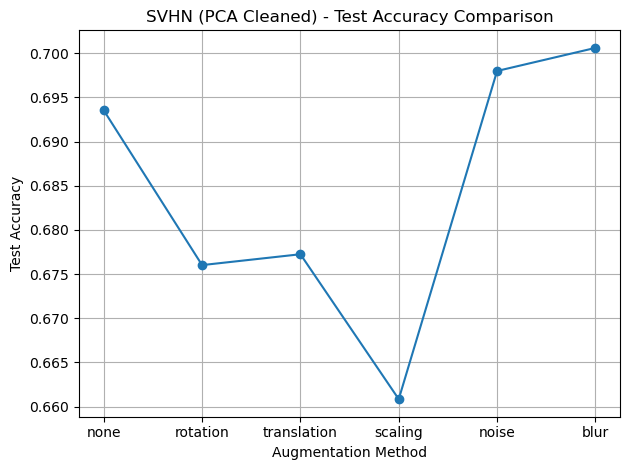

In [18]:
order = ["none", "rotation", "translation", "scaling", "noise", "blur"]
plot_df = results_df.copy()
plot_df["Augmentation Method"] = pd.Categorical(plot_df["Augmentation Method"], categories=order, ordered=True)
plot_df = plot_df.sort_values("Augmentation Method")

plt.figure()
plt.plot(plot_df["Augmentation Method"], plot_df["Test Accuracy"], marker="o")
plt.xlabel("Augmentation Method")
plt.ylabel("Test Accuracy")
plt.title("SVHN (PCA Cleaned) - Test Accuracy Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


- The result of line chart indicates that the image enrichment method with the worst effect is the Scaler, while the best one is the Blur.
- The experiment with Noise enrichment result in the second best accuracy.
- In addition, the Rotation and Translation have similar worse performances than no processing, because the change of these enrichment methods disrupted sequential representation used by the SimpleRNN model, making it harder to learn.